##Домашнее задание 2. Логистическая регрессия. Предсказание погоды.

В качестве домашнего задания вам предлагается поработать над предсказанием погоды. Файл с данными вы найдете в соответствующей директории. Вам будет доступен датасет weather.csv, ПЕРВЫЕ 75% (shuffle = False) которого нужно взять для обучения, последние 25% - для тестирования.

Требуется построить 4 модели которые будут предсказывать целевую переменную <b>RainTomorrow</b> с помощью:

   1. логистической регрессии [sklearn.linear_model.LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression)
   
   2. метода ближайших соседей [sklearn.neighbors](https://scikit-learn.org/stable/modules/neighbors.html)

   3. Байесовского классификатора [sklearn.naive_bayes](https://scikit-learn.org/stable/modules/naive_bayes.html)
   
   4. логистической регрессии реализованной самостоятельно

Затем следует сравнить результаты моделей (по качеству и времени выполнения) и сделать вывод о том, какая модель и с какими параметрами даёт лучшие результаты.

Не забывайте о том, что работа с признаками играет очень большую роль в построении хорошей модели.

Краткое описание данных:

    Date - Дата наблюдений
    Location - Название локации, в которой расположена метеорологическая станция
    MinTemp - Минимальная температура в градусах цельсия
    MaxTemp - Максимальная температура в градусах цельсия
    Rainfall - Количество осадков, зафиксированных за день в мм
    Evaporation - Так называемое "pan evaporation" класса А (мм) за 24 часа до 9 утра
    Sunshine - Число солнечных часов за день
    WindGustDir - направление самого сильного порыва ветра за последние 24 часа
    WindGustSpeed - скорость (км / ч) самого сильного порыва ветра за последние 24 часа
    WindDir9am - направление ветра в 9 утра

Начало реализации домашнего задания.

In [ ]:
!pip install category_encoders

В блоке ниже ничего особенного. Просто библиотеки и функции, нужные для работы. Активирование этого блока никакой информаии не выведет, но для самой работы его нужно активировать.

In [ ]:
import time
import math
import pandas as pd
import numpy as np
import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt
from category_encoders import BinaryEncoder
from scipy.stats import norm
from statistics import mean
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn import neighbors, naive_bayes
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

windDirDict = {'NNE': np.pi / 8, 'NE': np.pi / 4, 'ENE': 3 * np.pi / 8, 'E': np.pi / 2,
               'ESE': 5 * np.pi / 8, 'SE': 3 * np.pi / 4, 'SSE': 7 * np.pi / 8, 'S': np.pi,
               'SSW': 9 * np.pi / 8, 'SW': 5 * np.pi / 4, 'WSW': 11 * np.pi / 8, 'W': 3 * np.pi / 2,
               'WNW': 13 * np.pi / 8, 'NW': 7 * np.pi / 4, 'NNW': 15 * np.pi / 8, 'N': .0}

def ConvertAngleToRadians(df, colName):
  angleArr = np.zeros(len(df), dtype=float)
  for i, j in enumerate(df[colName].index):
    strAngle = df[colName][j]
    if strAngle == strAngle: angleArr[i] = windDirDict[strAngle]
    else: angleArr[i] = np.nan
  df.drop(colName, axis=1, inplace=True)
  if (colName == 'WindGustDir'): return df.assign(WindGustDir=angleArr)
  if (colName == 'WindDir9am'): return df.assign(WindDir9am=angleArr)
  if (colName == 'WindDir3pm'): return df.assign(WindDir3pm=angleArr)

def SplitDate(df):
  year = np.zeros(len(df), dtype=int)
  month = np.zeros(len(df), dtype=int)
  day = np.zeros(len(df), dtype=int)
  for i, j in enumerate(df.index):
    strDate = df['Date'][j]
    year[i] = int(strDate.split('-')[0])
    month[i] = int(strDate.split('-')[1])
    day[i] = int(strDate.split('-')[2])
  df.drop('Date', axis=1, inplace=True)
  return df.assign(Year=year, Month=month, Day=day)

def FillRainFieldsByNum(df):
  arrRainToday = np.zeros(len(df), dtype=int)
  arrRainTomorrow = np.zeros(len(df), dtype=int)
  for i, j in enumerate(df.index):
    if df['RainToday'][j] == 'Yes':
      arrRainToday[i] = 1
    if df['RainTomorrow'][j] == 'Yes':
      arrRainTomorrow[i] = 1
  df.drop(['RainToday', 'RainTomorrow'], axis = 1, inplace = True)
  return df.assign(RainToday=arrRainToday, RainTomorrow=arrRainTomorrow)

def CalcMeanWindAngle(angleArr, speedArr) :
  xSum = np.nan
  ySum = np.nan
  for i in angleArr.index:
    if xSum != xSum and angleArr[i] == angleArr[i] and speedArr[i] == speedArr[i] :
      xSum = speedArr[i] * np.cos(angleArr[i])
      ySum = speedArr[i] * np.sin(angleArr[i])
      continue
    if angleArr[i] == angleArr[i] and speedArr[i] == speedArr[i] :
      xSum += speedArr[i] * np.cos(angleArr[i])
      ySum += speedArr[i] * np.sin(angleArr[i])
  if xSum == xSum and ySum == ySum:
    if not(xSum > 0) and not(xSum < 0) :
      if ySum > 0: return np.pi / 2
      elif ySum < 0: return 3 * np.pi / 2
      else: return np.nan
    avgAngle = math.atan2(ySum, xSum)
    if avgAngle < 0 : return avgAngle + 2 * np.pi
    return avgAngle
  return np.nan

def CalcMeanWindSpeed(speedArr, angleArr) :
  xSum = np.nan
  ySum = np.nan
  j = 0
  for i in speedArr.index:
    if xSum != xSum and angleArr[i] == angleArr[i] and speedArr[i] == speedArr[i] :
      xSum = speedArr[i] * np.cos(angleArr[i])
      ySum = speedArr[i] * np.sin(angleArr[i])
      j += 1
      continue
    if angleArr[i] == angleArr[i] and speedArr[i] == speedArr[i] :
      xSum += speedArr[i] * np.cos(angleArr[i])
      ySum += speedArr[i] * np.sin(angleArr[i])
      j += 1
  if xSum == xSum and ySum == ySum:
    xSum = xSum / j
    ySum = ySum / j
    return np.sqrt(xSum*xSum + ySum*ySum)
  return np.nan

def FillNaAnglesByGroup(df, groupLst):
  df1 = df[groupLst + ['WindGustDir']].groupby(groupLst, sort=False).transform(lambda x: x.fillna(CalcMeanWindAngle(x, df['WindGustSpeed'])))
  df2 = df[groupLst + ['WindDir9am']].groupby(groupLst, sort=False).transform(lambda x: x.fillna(CalcMeanWindAngle(x, df['WindSpeed9am'])))
  df3 = df[groupLst + ['WindDir3pm']].groupby(groupLst, sort=False).transform(lambda x: x.fillna(CalcMeanWindAngle(x, df['WindSpeed3pm'])))
  df.drop(['WindGustDir', 'WindDir9am', 'WindDir3pm'], axis=1, inplace=True)
  return df.assign(WindGustDir=df1['WindGustDir'], WindDir9am=df2['WindDir9am'], WindDir3pm=df3['WindDir3pm'])

def FillNaSpeedsByGroup(df, groupLst):
  df1 = df[groupLst + ['WindGustSpeed']].groupby(groupLst, sort=False).transform(lambda x: x.fillna(CalcMeanWindSpeed(x, df['WindGustDir'])))
  df2 = df[groupLst + ['WindSpeed9am']].groupby(groupLst, sort=False).transform(lambda x: x.fillna(CalcMeanWindSpeed(x, df['WindDir9am'])))
  df3 = df[groupLst + ['WindSpeed3pm']].groupby(groupLst, sort=False).transform(lambda x: x.fillna(CalcMeanWindSpeed(x, df['WindDir3pm'])))
  df.drop(['WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm'], axis=1, inplace=True)
  return df.assign(WindGustSpeed=df1['WindGustSpeed'], WindSpeed9am=df2['WindSpeed9am'], WindSpeed3pm=df3['WindSpeed3pm'])

def FillNaTempsByGroup(df, groupLst):
  df1 = df[groupLst + ['MinTemp']].groupby(groupLst, sort=False).transform(lambda x: x.fillna(x.mean()))
  df2 = df[groupLst + ['MaxTemp']].groupby(groupLst, sort=False).transform(lambda x: x.fillna(x.mean()))
  df3 = df[groupLst + ['Temp9am']].groupby(groupLst, sort=False).transform(lambda x: x.fillna(x.mean()))
  df4 = df[groupLst + ['Temp3pm']].groupby(groupLst, sort=False).transform(lambda x: x.fillna(x.mean()))
  df.drop(['MinTemp', 'MaxTemp', 'Temp9am', 'Temp3pm'], axis=1, inplace=True)
  return df.assign(MinTemp=df1['MinTemp'], MaxTemp=df2['MaxTemp'], Temp9am=df3['Temp9am'], Temp3pm=df4['Temp3pm'])

def FillNaHumidityByGroup(df, groupLst):
  df1 = df[groupLst + ['Humidity9am']].groupby(groupLst, sort=False).transform(lambda x: x.fillna(x.mean()))
  df2 = df[groupLst + ['Humidity3pm']].groupby(groupLst, sort=False).transform(lambda x: x.fillna(x.mean()))
  df.drop(['Humidity9am', 'Humidity3pm'], axis=1, inplace=True)
  return df.assign(Humidity9am=df1['Humidity9am'], Humidity3pm=df2['Humidity3pm'])

def FillNaPressureByGroup(df, groupLst):
  df1 = df[groupLst + ['Pressure9am']].groupby(groupLst, sort=False).transform(lambda x: x.fillna(x.mean()))
  df2 = df[groupLst + ['Pressure3pm']].groupby(groupLst, sort=False).transform(lambda x: x.fillna(x.mean()))
  df.drop(['Pressure9am', 'Pressure3pm'], axis=1, inplace=True)
  return df.assign(Pressure9am=df1['Pressure9am'], Pressure3pm=df2['Pressure3pm'])

def FillNaCloudByGroup(df, groupLst):
  df1 = df[groupLst + ['Cloud9am']].groupby(groupLst, sort=False).transform(lambda x: x.fillna(x.mean()))
  df2 = df[groupLst + ['Cloud3pm']].groupby(groupLst, sort=False).transform(lambda x: x.fillna(x.mean()))
  df.drop(['Cloud9am', 'Cloud3pm'], axis=1, inplace=True)
  return df.assign(Cloud9am=df1['Cloud9am'], Cloud3pm=df2['Cloud3pm'])

def FillNaSunshineByGroup(df, groupLst):
  df1 = df[groupLst + ['Sunshine']].groupby(groupLst, sort=False).transform(lambda x: x.fillna(x.mean()))
  df.drop(['Sunshine'], axis=1, inplace=True)
  return df.assign(Sunshine=df1['Sunshine'])

def FillNaEvaporationByGroup(df, groupLst):
  df1 = df[groupLst + ['Evaporation']].groupby(groupLst, sort=False).transform(lambda x: x.fillna(x.mean()))
  df.drop(['Evaporation'], axis=1, inplace=True)
  return df.assign(Evaporation=df1['Evaporation'])

def FillNaRainfallByGroup(df, groupLst):
  df1 = df[groupLst + ['Rainfall']].groupby(groupLst, sort=False).transform(lambda x: x.fillna(x.mean()))
  df.drop(['Rainfall'], axis=1, inplace=True)
  return df.assign(Rainfall=df1['Rainfall'])

Считываем данные в датафрейм df:

In [ ]:
df = pd.read_csv('weather.csv')
df.head(10)

,Unnamed: 0,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No
5,5,2008-12-06,Albury,14.6,29.7,0.2,NaN,NaN,WNW,56.0,...,55.0,23.0,1009.2,1005.4,NaN,NaN,20.6,28.9,No,No
6,6,2008-12-07,Albury,14.3,25.0,0.0,NaN,NaN,W,50.0,...,49.0,19.0,1009.6,1008.2,1.0,NaN,18.1,24.6,No,No
7,7,2008-12-08,Albury,7.7,26.7,0.0,NaN,NaN,W,35.0,...,48.0,19.0,1013.4,1010.1,NaN,NaN,16.3,25.5,No,No
8,8,2008-12-09,Albury,9.7,31.9,0.0,NaN,NaN,NNW,80.0,...,42.0,9.0,1008.9,1003.6,NaN,NaN,18.3,30.2,No,Yes
9,9,2008-12-10,Albury,13.1,30.1,1.4,NaN,NaN,W,28.0,...,58.0,27.0,1007.0,1005.7,NaN,NaN,20.1,28.2,Yes,No


Выясним процент пропусков в столбцах:

In [ ]:
(df.isna().sum() / len(df)).round(4) * 100

Unnamed: 0        0.00
Date              0.00
Location          0.00
MinTemp           0.45
MaxTemp           0.23
Rainfall          0.99
Evaporation      42.79
Sunshine         47.69
WindGustDir       6.56
WindGustSpeed     6.52
WindDir9am        7.04
WindDir3pm        2.66
WindSpeed9am      0.95
WindSpeed3pm      1.85
Humidity9am       1.25
Humidity3pm       2.54
Pressure9am       9.86
Pressure3pm       9.83
Cloud9am         37.74
Cloud3pm         40.15
Temp9am           0.64
Temp3pm           1.92
RainToday         0.99
RainTomorrow      0.00
dtype: float64

Видно, что очень много пропусков в таких столбцах как 'Evaporation', 'Sunshine', 'Cloud9am', 'Cloud3pm'.

Посмотрим более наглядно, как распределены эти пропуски:

<Axes: >

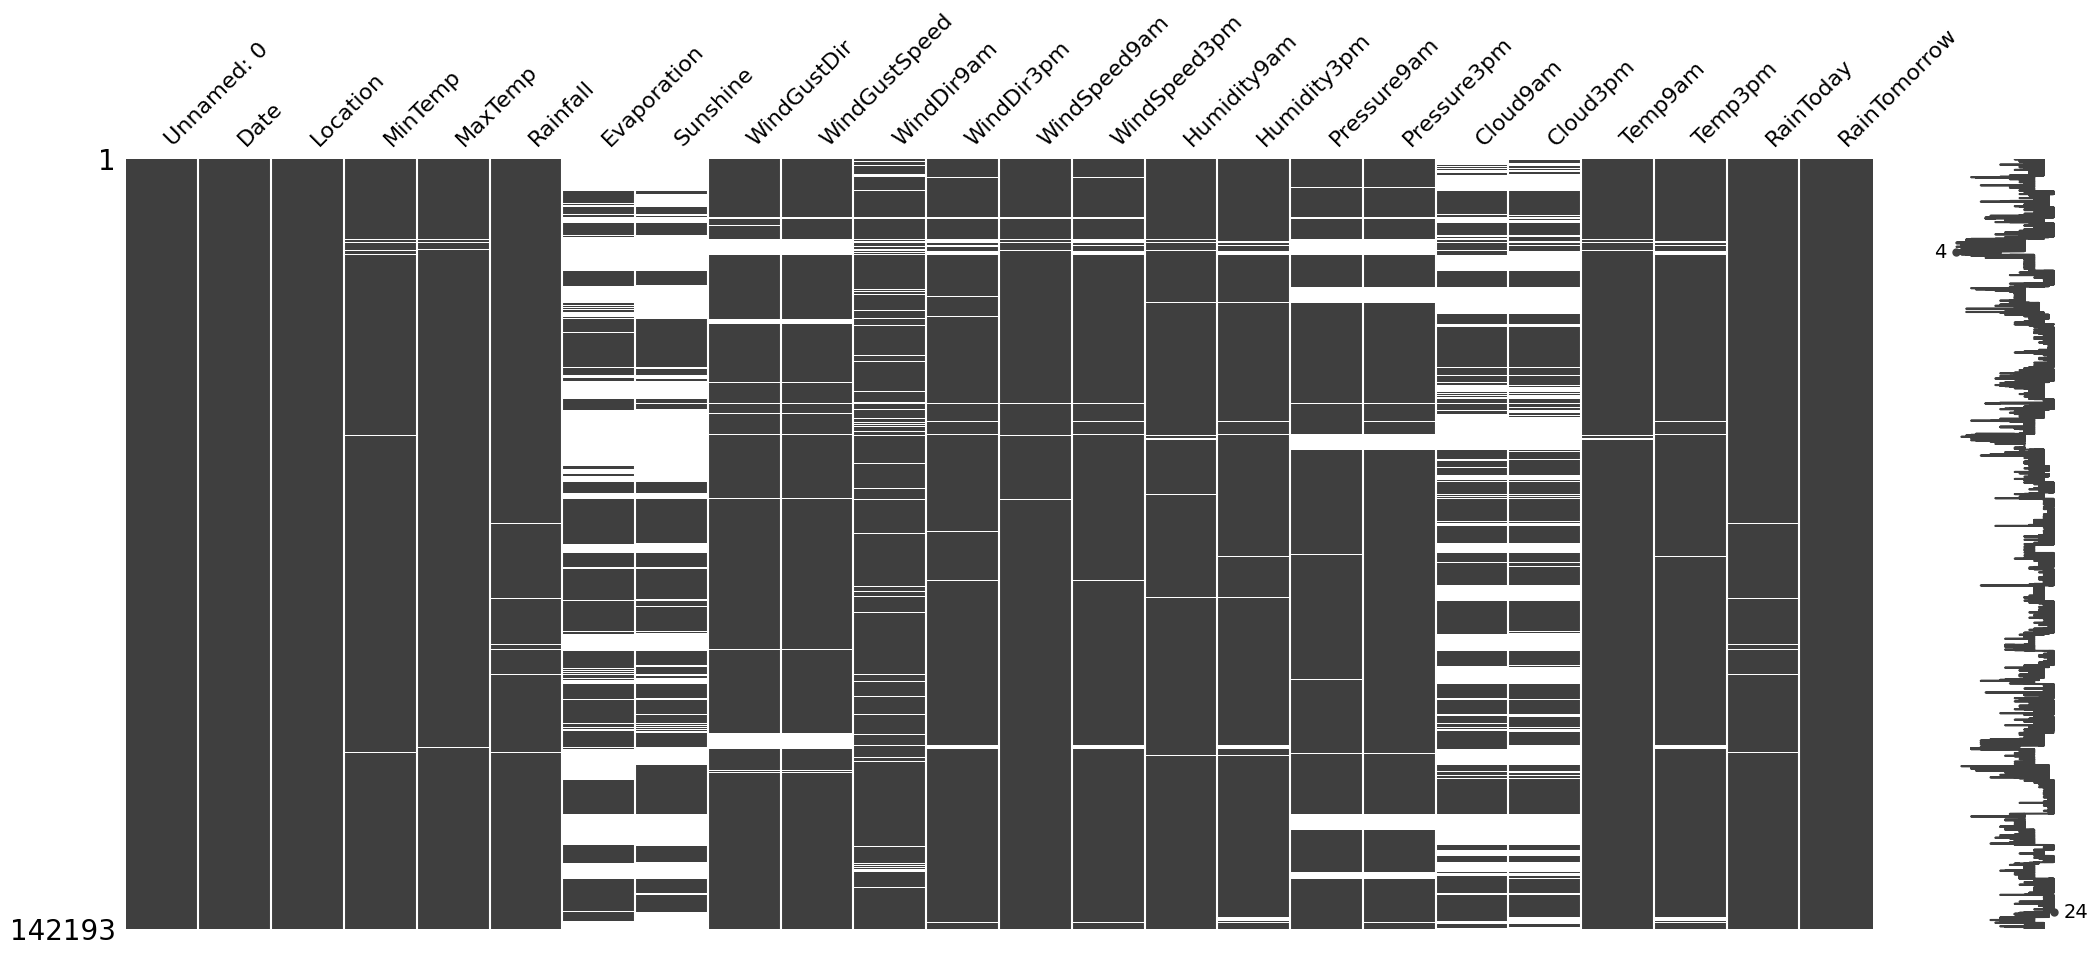

In [ ]:
msno.matrix(df)

1) **Работа с признаками**

Видно очень много пропусков. Причём характер пропусков не очень хороший. Есть некоторые довольно размашистые блоки дат, где прямо подряд идут пропуски. Это может натолкнуть на то, что есть какие-то внешние обстоятельства этих пропусков, которые не учтены в датасете.

Но попробуем как-то заполнить хоть часть пропусков. Очевидно, что погода изменчива в рамках какой-то локации и в рамках месяца (если широта умеренная). При заполнении это можно учесть. Так же многие параметры погоды зависят от того, есть ли дождь или нет. Например, когда дождь есть, давление как правило ниже.

In [ ]:
dfFilled = df
#Разбивка даты на численные признаки (год, месяц, день):
dfFilled = SplitDate(dfFilled)
#Заполнение признаков-индикаторов дождя числовыми переменными (No -> 0, NaN -> 0, Yes -> 1):
dfFilled = FillRainFieldsByNum(dfFilled)
#Преобразование категориального направления в численное (угол в радианах):
dfFilled = ConvertAngleToRadians(dfFilled, 'WindGustDir')
dfFilled = ConvertAngleToRadians(dfFilled, 'WindDir9am')
dfFilled = ConvertAngleToRadians(dfFilled, 'WindDir3pm')
#Заполнение пустых значений средними по группам:
#Логично брать группировать по таким категориям как локация и месяц.
#При таком заполнении репрезентативность более-менее должна сохраниться.
#Потому что у каждой локации свой климат, и по месяцам разная погода (особенно в умеренных широтах):
dfFilled = FillNaAnglesByGroup(dfFilled, ['RainToday', 'Location', 'Month'])
dfFilled = FillNaSpeedsByGroup(dfFilled, ['RainToday', 'Location', 'Month'])
dfFilled = FillNaTempsByGroup(dfFilled, ['RainToday', 'Location', 'Month'])
dfFilled = FillNaHumidityByGroup(dfFilled, ['RainToday', 'Location', 'Month'])
dfFilled = FillNaPressureByGroup(dfFilled, ['RainToday', 'Location', 'Month'])
dfFilled = FillNaCloudByGroup(dfFilled, ['RainToday', 'Location', 'Month'])
dfFilled = FillNaSunshineByGroup(dfFilled, ['RainToday', 'Location', 'Month'])
dfFilled = FillNaEvaporationByGroup(dfFilled, ['RainToday', 'Location', 'Month'])
dfFilled = FillNaRainfallByGroup(dfFilled, ['RainToday', 'Location', 'Month'])

Посмотрим, как изменится ситуация с пропусками, после разбивки даты, преобразования направлений в радианы и заполнений пустых значений средними по группам: 'RainToday', 'Location' и 'Month':

In [ ]:
dfFilled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142193 entries, 0 to 142192
Data columns (total 26 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Unnamed: 0     142193 non-null  int64  
 1   Location       142193 non-null  object 
 2   Year           142193 non-null  int64  
 3   Month          142193 non-null  int64  
 4   Day            142193 non-null  int64  
 5   RainToday      142193 non-null  int64  
 6   RainTomorrow   142193 non-null  int64  
 7   WindGustDir    136222 non-null  float64
 8   WindDir9am     142193 non-null  float64
 9   WindDir3pm     142193 non-null  float64
 10  WindGustSpeed  136222 non-null  float64
 11  WindSpeed9am   142193 non-null  float64
 12  WindSpeed3pm   142193 non-null  float64
 13  MinTemp        142193 non-null  float64
 14  MaxTemp        142193 non-null  float64
 15  Temp9am        142193 non-null  float64
 16  Temp3pm        142187 non-null  float64
 17  Humidity9am    142193 non-nul

Немного смягчим критерии группировки, убрав из группирующих признаков 'RainToday':

In [ ]:
dfFilled = FillNaAnglesByGroup(dfFilled, ['Location', 'Month'])
dfFilled = FillNaSpeedsByGroup(dfFilled, ['Location', 'Month'])
dfFilled = FillNaTempsByGroup(dfFilled, ['Location', 'Month'])
dfFilled = FillNaHumidityByGroup(dfFilled, ['Location', 'Month'])
dfFilled = FillNaPressureByGroup(dfFilled, ['Location', 'Month'])
dfFilled = FillNaCloudByGroup(dfFilled, ['Location', 'Month'])
dfFilled = FillNaSunshineByGroup(dfFilled, ['Location', 'Month'])
dfFilled = FillNaEvaporationByGroup(dfFilled, ['Location', 'Month'])

Смотрим результат:

In [ ]:
dfFilled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142193 entries, 0 to 142192
Data columns (total 26 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Unnamed: 0     142193 non-null  int64  
 1   Location       142193 non-null  object 
 2   Year           142193 non-null  int64  
 3   Month          142193 non-null  int64  
 4   Day            142193 non-null  int64  
 5   RainToday      142193 non-null  int64  
 6   RainTomorrow   142193 non-null  int64  
 7   Rainfall       142193 non-null  float64
 8   WindGustDir    136222 non-null  float64
 9   WindDir9am     142193 non-null  float64
 10  WindDir3pm     142193 non-null  float64
 11  WindGustSpeed  136222 non-null  float64
 12  WindSpeed9am   142193 non-null  float64
 13  WindSpeed3pm   142193 non-null  float64
 14  MinTemp        142193 non-null  float64
 15  MaxTemp        142193 non-null  float64
 16  Temp9am        142193 non-null  float64
 17  Temp3pm        142193 non-nul

<Axes: >

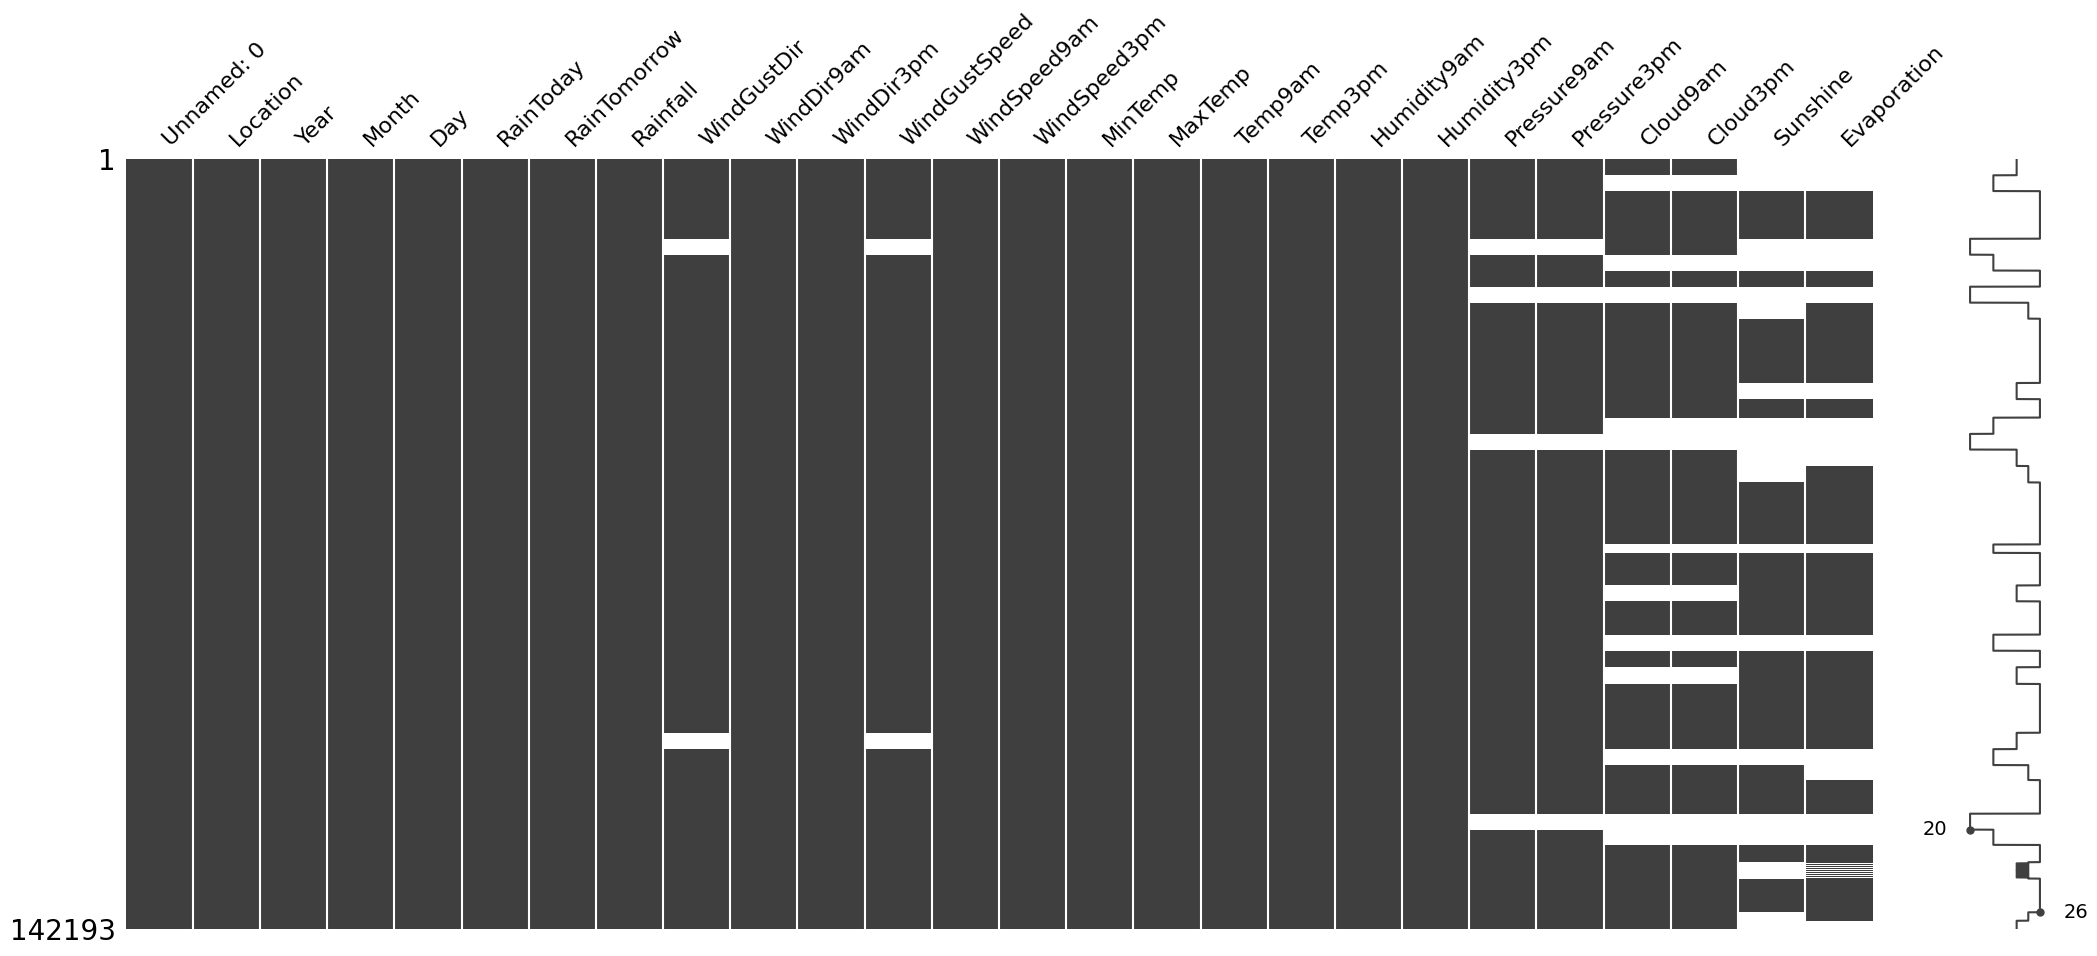

In [ ]:
msno.matrix(dfFilled)

По карте пропусков видно, что ситуация улучшилась и многие столбцы полностью заполнились. Но по прежнему в некоторых столбцах осталось большое кол-во пропусков.
Очевидно, что эти пропуски неслучайны. Выделяются конкретные последовательные блоки дат, когда заполнения не делались. Причём выделение по группам никак не спасло положение. Как минимум в рамках конкретных пар локации и месяца многие признаки не заполнялись метеорологами.

У меня есть предположение, что это связано с тем, что эти данные (где очень много пропусков) не настолько важны, чтобы их измерять. Поэтому если случился какой-то форс-мажор (например, поломка оборудования), то его починка или замена была не к спеху, и некоторые данные можно было просто не замерять, потому что они были не особо важные.

Чтобы проверить эту гипотезу, построим корреляционную матрицу.

Но перед этим не забываем закодировать категориальный признак 'Location'. В принципе, он в таком виде нам больше не нужен (мы все групперовки по нему сделали), поэтому это уместно. Я буду использовать BinaryEncoder, так как датасет и так не маленький, а проклятье размерности никто не отменял.

In [ ]:
encoder = BinaryEncoder(cols =['Location'])
newdata = encoder.fit_transform(dfFilled['Location'])
dfFilled = pd.concat([dfFilled, newdata], axis = 1)
dfFilled = dfFilled.drop(['Location'], axis = 1)

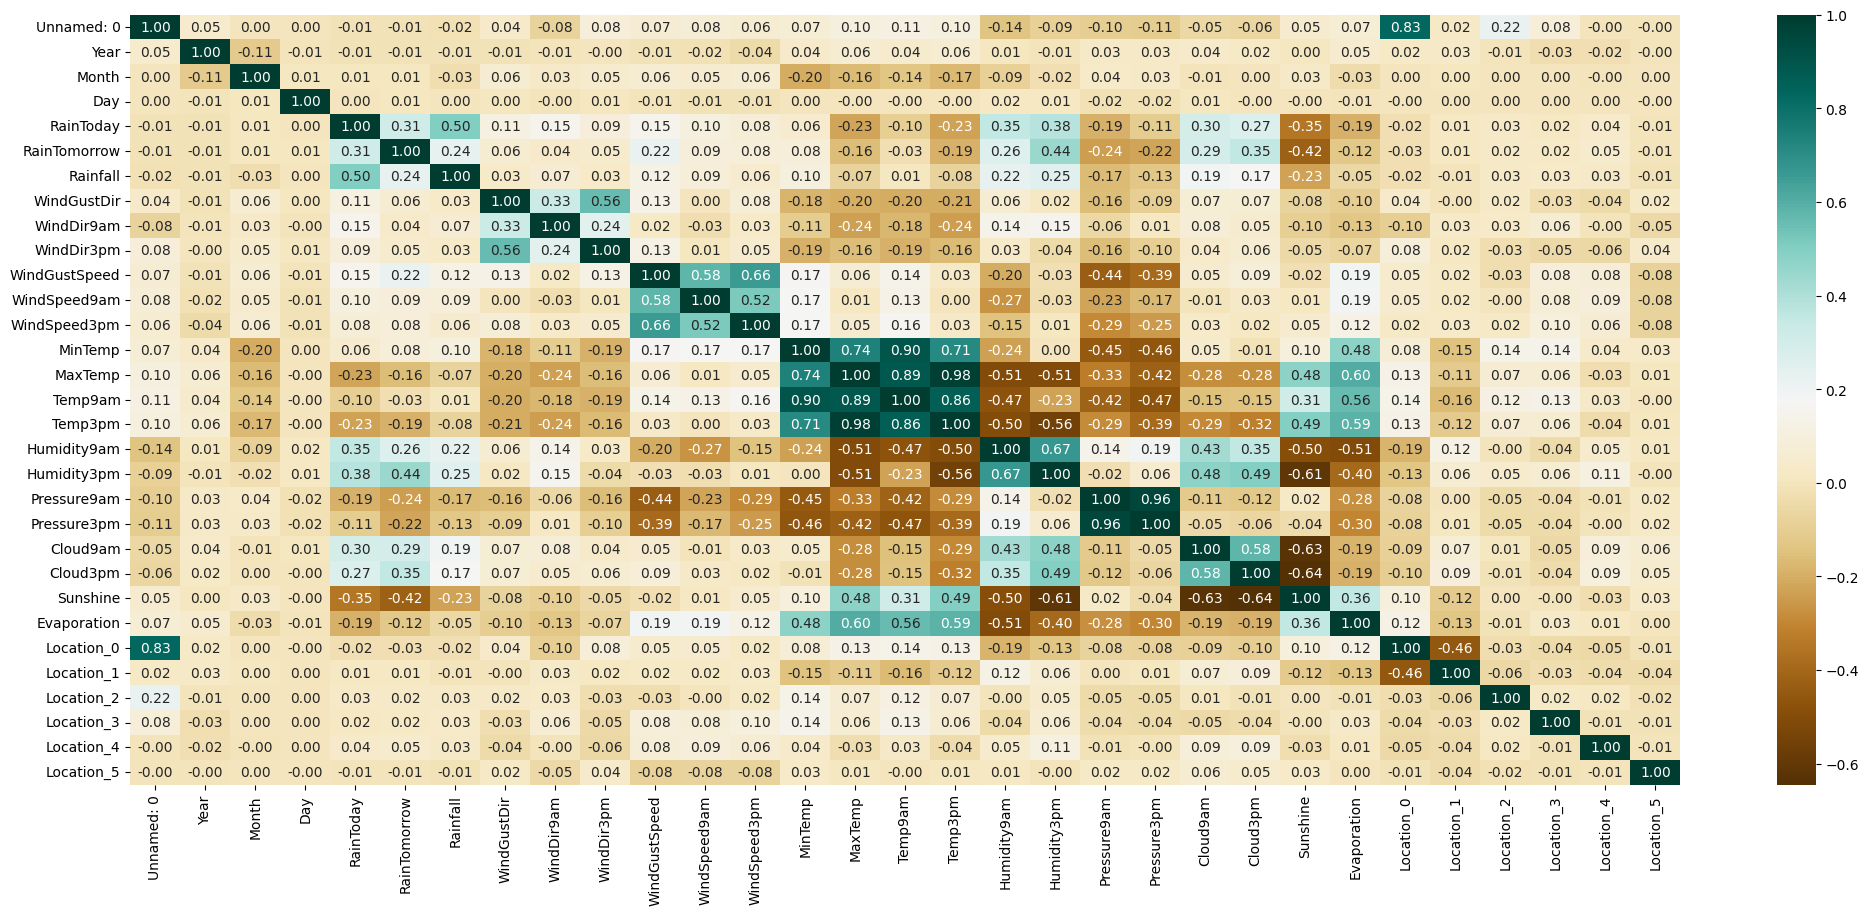

In [ ]:
plt.figure(figsize=(25, 10))
sns.heatmap(dfFilled.corr(), annot=True, fmt = '.2f', cmap='BrBG')
plt.show()

Если смотреть на строку матрицы 'RainTomorrow', то можно увидеть интересные вещи.

Столбцы с большим количеством пропусков: 'Sunshine', 'Evaporation', 'Cloud9am', 'Cloud3pm' имеют достаточно весомые корреляции с целевой переменной 'RainTomorrow'. Но давайте вспомним наше предположение.

Может быть эти данные не особо важны, и они не несут в себе много информации для прогноза, раз люди не особо заботились за их заполнением? Возможно они как-то скрыто связаны с другими переменными. Причём это может быть не обязательно линейная зависимость.

Например.

1) 'RainTomorrow' зависит от 'Humidity3pm' положительно на 0.44.

2) 'RainTomorrow' зависит от 'Sunshine' отрицательно на -0.42.

3) 'Humidity3pm' зависит от 'Sunshine' отрицательно на -0.6.

4) 'RainTomorrow' зависит одновременно от 'Humidity3pm' и 'Sunshine'.

Всё это наталкивает на мысль, что вклад 'Sunshine' в определение 'RainTomorrow' практически полностью лежит в 'Humidity3pm' в тех самых -0.6 корреляции.

Поэтому можно попробовать удалить полностью столбец 'Sunshine' c большим количеством пропусков. В любом случае его невозможно адекватно заполнить с учётом имеющихся данных. Уверенно можно сказать, что причины незаполнения какие-то внешние, и угадывать эти причины для заполнения неконструктивно. Проще оценить весомость причин незаполнения и в случае убедительной причины удалить эти признаки. Тут мы указали на возможную поломку и не срочность ремонта/замены конкретных датчиков. На мой взгляд, это убедительная причина.

Абсолютно так же по схожей логике можно поступить с такими столбцами как 'Evaporation', 'Cloud9am', 'Cloud3pm'. Опять же, это всё имеет смысл делать, когда в столбцах ощутимое количество неслучайных пропусков.

Касательно столбцов: 'Pressure9am', 'Pressure3pm', 'WindGustSpeed', 'WindGustDir' можно поступить следующим образом. Так как в них всего по 2-4 блока пропусков, да и размеры этих блоков не большие, то ничего не поделаешь. Удалять эти столбцы нельзя, так как пропусков в них мало, а полезных данных может быть в них много. Придётся ещё больше смягчать критерии группировки.

Ниже осуществляется группировка только по признаку 'RainToday'

In [ ]:
dfFilled = dfFilled.drop(['Evaporation', 'Sunshine', 'Cloud9am', 'Cloud3pm'], axis=1)
dfFilled = FillNaAnglesByGroup(dfFilled, ['RainToday'])
dfFilled = FillNaSpeedsByGroup(dfFilled, ['RainToday'])
dfFilled = FillNaPressureByGroup(dfFilled, ['RainToday'])

Убеждаемся, что все признаки с большим кол-вом пропусков удалены, и в оставшихся признаках всё заполнено:

In [ ]:
dfFilled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142193 entries, 0 to 142192
Data columns (total 27 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Unnamed: 0     142193 non-null  int64  
 1   Year           142193 non-null  int64  
 2   Month          142193 non-null  int64  
 3   Day            142193 non-null  int64  
 4   RainToday      142193 non-null  int64  
 5   RainTomorrow   142193 non-null  int64  
 6   Rainfall       142193 non-null  float64
 7   MinTemp        142193 non-null  float64
 8   MaxTemp        142193 non-null  float64
 9   Temp9am        142193 non-null  float64
 10  Temp3pm        142193 non-null  float64
 11  Humidity9am    142193 non-null  float64
 12  Humidity3pm    142193 non-null  float64
 13  Location_0     142193 non-null  int64  
 14  Location_1     142193 non-null  int64  
 15  Location_2     142193 non-null  int64  
 16  Location_3     142193 non-null  int64  
 17  Location_4     142193 non-nul

Корреляционная матрица после финальной подготовки даных:

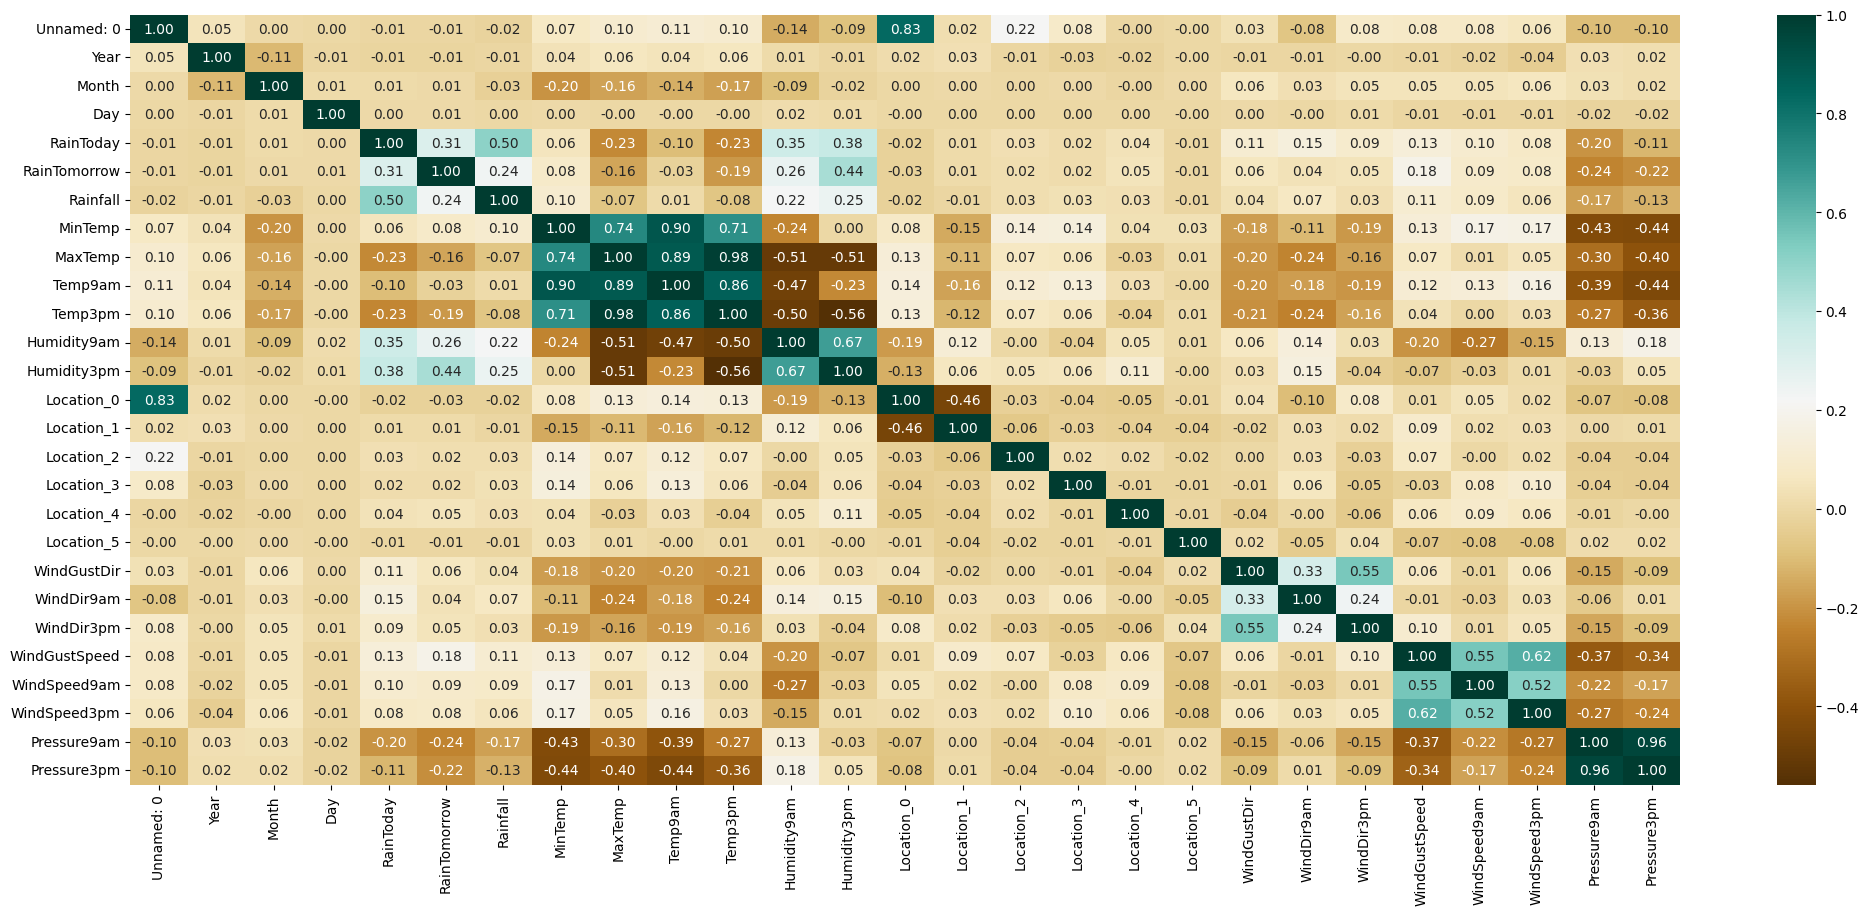

In [ ]:
plt.figure(figsize=(25, 10))
sns.heatmap(dfFilled.corr(), annot=True, fmt = '.2f', cmap='BrBG')
plt.show()

Удаляем ненужные и крайне слабо коррелирующие с целевой переменной признаки:

In [ ]:
dfFiltered = dfFilled
dfFiltered.drop(['Unnamed: 0', 'Year', 'Month', 'Day', 'WindDir9am', 'Temp9am',
                   'Location_0', 'Location_1', 'Location_2', 'Location_3', 'Location_5'], axis=1, inplace=True)

2) **Разделение данных на тренировочную и тестовую выборки**

Разделяем подготовленный датафрейм на тренировочную и тестовую вбыорки. Это допустимо делать после подготовки. Если бы у нас была тестовая выборка отдельно, мы бы просто соединили её с тренировочной, и сделали бы всю подготовку признаков аналогичным образом. Отсутствие целевой переменной в тестовой выборке никак бы не помешало нам подготовить признаки.

В любом случае при прогонке через модель, мы бы тестовую выборку отделили в отдельный датафрейм.

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(dfFiltered.drop(['RainTomorrow'], axis = 1), dfFiltered['RainTomorrow'], test_size=0.25, shuffle=False)
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

3) **Логистическая регрессия (библиотечная)**

In [ ]:
LR = LogisticRegression()
start = time.time()
LR.fit(x_train, y_train)
end = time.time()
print("Время обучения: {}".format(end - start))
start = time.time()
y_pred = LR.predict(x_train)
end = time.time()
print("Время предсказания для тренировочной выборки: {}".format(end - start))
accuracy_train = accuracy_score(y_train, y_pred)
start = time.time()
y_pred = LR.predict(x_test)
end = time.time()
print("Время предсказания для тестовой выборки: {}".format(end - start))
accuracy_test = accuracy_score(y_test, y_pred)
print("Accuracy train: {:.2f}%".format(accuracy_train * 100))
print("Accuracy test: {:.2f}%".format(accuracy_test * 100))

Время обучения: 0.35563206672668457
Время предсказания для тренировочной выборки: 0.004658699035644531
Время предсказания для тестовой выборки: 0.0030181407928466797
Accuracy train: 83.64%
Accuracy test: 85.03%


4) **Метод K-ближайших соседей**

In [ ]:
fitTimesDict = {}
trainPredTimesDict = {}
testPredTimesDict = {}
knnScoresTrain = {}
knnScoresTest = {}
for k in range(1, 11):
  knn_model = KNeighborsClassifier(n_neighbors=k)
  start = time.time()
  knn_model.fit(x_train, y_train)
  end = time.time()
  fitTimesDict[k] = round(end - start, 2)
  start = time.time()
  knnScoresTrain[k] = round(knn_model.score(x_train, y_train) * 100, 2)
  end = time.time()
  trainPredTimesDict[k] = round(end - start, 2)
  start = time.time()
  knnScoresTest[k] = round(knn_model.score(x_test, y_test) * 100, 2)
  end = time.time()
  testPredTimesDict[k] = round(end - start, 2)
print('Вывод времени обучения для каждого n_neighbors = 1..10\n\n', fitTimesDict)
print('\nВывод времени предсказания тренировочной выборки для каждого n_neighbors = 1..10\n\n', trainPredTimesDict)
print('\nВывод времени предсказания тестовой выборки для каждого n_neighbors = 1..10\n\n', testPredTimesDict)
print('\nВывод скора на тренировочной выборке для каждого n_neighbors = 1..10\n\n', knnScoresTrain)
print('\nВывод скора на тестовой выборке для каждого n_neighbors = 1..10\n\n', knnScoresTest)

Вывод времени обучения для каждого n_neighbors = 1..10

 {1: 0.35, 2: 0.3, 3: 0.3, 4: 0.3, 5: 0.3, 6: 0.3, 7: 0.31, 8: 0.29, 9: 0.29, 10: 0.3}

Вывод времени предсказания тренировочной выборки для каждого n_neighbors = 1..10

 {1: 14.13, 2: 60.91, 3: 69.06, 4: 73.43, 5: 80.59, 6: 83.29, 7: 89.79, 8: 89.59, 9: 97.09, 10: 95.67}

Вывод времени предсказания тестовой выборки для каждого n_neighbors = 1..10

 {1: 24.7, 2: 28.4, 3: 30.56, 4: 31.82, 5: 35.62, 6: 36.11, 7: 38.01, 8: 37.11, 9: 39.41, 10: 39.38}

Вывод скора на тренировочной выборке для каждого n_neighbors = 1..10

 {1: 100.0, 2: 88.91, 3: 89.7, 4: 87.11, 5: 87.59, 6: 86.27, 7: 86.62, 8: 85.85, 9: 86.16, 10: 85.59}

Вывод скора на тестовой выборке для каждого n_neighbors = 1..10

 {1: 78.07, 2: 81.36, 3: 81.81, 4: 82.47, 5: 82.92, 6: 83.09, 7: 83.38, 8: 83.36, 9: 83.65, 10: 83.57}


5) **Гауссов наивный байесовский классификатор**

In [ ]:
gnb = GaussianNB()
start = time.time()
gnb.fit(x_train, y_train)
end = time.time()
print("Время обучения: {}".format(end - start))
start = time.time()
y_pred = gnb.predict(x_train)
end = time.time()
print("Время предсказания для тренировочной выборки: {}".format(end - start))
accuracyTrain = accuracy_score(y_train, y_pred)
start = time.time()
y_pred = gnb.predict(x_test)
end = time.time()
print("Время предсказания для тестовой выборки: {}".format(end - start))
accuracyTest = accuracy_score(y_test, y_pred)
print("Accuracy Train: {:.2f}%".format(accuracyTrain * 100))
print("Accuracy Test: {:.2f}%".format(accuracyTest * 100))

Время обучения: 0.04808306694030762
Время предсказания для тренировочной выборки: 0.019936323165893555
Время предсказания для тестовой выборки: 0.005805253982543945
Accuracy Train: 80.52%
Accuracy Test: 82.86%


6) **Своя логистическая регрессия**

$$p(y|x) = a(x, \theta) = \sigma(\langle x, \theta \rangle) = \frac{1}{1 + \exp(-\langle \theta, x_i \rangle)}$$

Это тестовые данные. Лучше их прожать для проверки функций.

In [ ]:
theta = np.array([1, 2, 3])

X =  np.array([[ 1,  1, 1],
               [-1, -2, 1],
               [-1, -2, 2],
               [-2, -2, -3]
              ])

y = np.array([1, 1, 0, 0])

Функция для классификации (вероятности принадлежности к классу)

In [ ]:
def probability(theta, X):
  result = 1.0 / (1 + np.exp(-np.dot(X, theta)))
  return result

prob = probability(theta, X)
assert type(prob) == np.ndarray, 'Возвращается неверный тип'
assert prob.shape == (X.shape[0],), 'Неверный размер массива'
assert (prob.round(3) == [0.998, 0.119, 0.731, 0.]).all(), 'Функция считается неверно'

Функция предсказания метки класса, получает на вход вероятности принадлежности к классу 1 и выдает метки классов $y \in \{0, 1\}$

In [ ]:
def binary_class_prediction(theta, X, threshold =.5):
  prob =  probability(theta, X)
  result = np.where(prob >= threshold, 1, 0)
  return result

y_pred = binary_class_prediction(theta, X)

assert type(y_pred) == np.ndarray, 'Возвращается неверный тип'
assert y_pred.shape == (X.shape[0],), 'Неверный размер массива'
assert min(y_pred) == 0, 'Функция считается неверно'
assert max(y_pred) == 1, 'Функция считается неверно'

__Функционал качества логистической регрессии__

Запишем правдободовие выборки для меток класса $y \in \{+1, -1\}$

$$Likelihood(a, X^\ell) = \prod_{i = 1}^{\ell} a(x_i,\theta)^{[y_i = +1]} (1 - a(x_i, \theta))^{[y_i = -1]} → \operatorname*{max}_{\theta}$$

Прологарифмируем правдоподобие выборки и перейдем к задаче минимизации:

$$Q(a, X^\ell) =     -\sum_{i = 1}^{\ell}
        [y_i = +1] \log a(x_i, \theta)
        +
        [y_i = -1] \log (1 - a(x_i, \theta)) \to \operatorname*{min}_{\theta}$$
        
Подставим $a(x, \theta)$ в функцинал качества:

$$ Q(a, X^\ell) = -\sum_{i = 1}^{\ell} \left(
    [y_i = +1]
    \log \frac{1}{1 + \exp(-\langle \theta, x_i \rangle)}
    +
    [y_i = -1]
    \log \frac{\exp(-\langle \theta, x_i \rangle)}{1 + \exp(-\langle \theta, x_i \rangle)}
\right)
\\
=
-\sum_{i = 1}^{\ell} \left(
    [y_i = +1]
    \log \frac{1}{1 + \exp(-\langle \theta, x_i \rangle)}
    +
    [y_i = -1]
    \log \frac{1}{1 + \exp(\langle \theta, x_i \rangle)}
\right)
\\
=
\sum_{i = 1}^{\ell}
    \log \left(
        1 + \exp(-y_i \langle \theta, x_i \rangle)
    \right) $$
    

Итоговый оптимизируемый функционал качества (logloss), записанный для меток классов $y \in \{+1, -1\}$ и усредненный по выборке

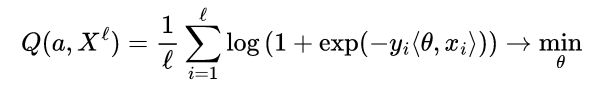

Реализуем его в функции logloss:

In [ ]:
def logloss(theta, X, y):
  yModified = np.where(y == 0, -1, 1)
  result = np.mean(np.log1p(np.exp(-yModified * np.dot(X, theta))))
  return result

In [ ]:
assert logloss(theta, X, y).round(3) == 0.861, 'Функция считается неверно'

__Алгоритм оптимизации функционала качества. Стохастический градиентный спуск__

<b>Вход: </b> Выборка $X^\ell$, темп обучения $h$

<b>Выход: </b> оптимальный вектор весов $\theta$

1.  Инициализировать веса $\theta$
2.  Инициализировать оценку функционала качества: $Q(a, X^\ell)$
3.  <b>Повторять</b>:

    Выбрать случайным образом подвыборку объектов $X^{batch} =\{x_1, \dots,x_n \}$ из $X^{\ell}$
    
    Рассчитать градиент функционала качества: $\nabla Q(X^{batch}, \theta)$
    
    Обновить веса: $\theta := \theta - h\cdot \nabla Q(X^{batch}, \theta)$
       
    <b>Пока</b> значение $Q$ и/или веса $\theta$ не сойдутся   

Реализуем функцию расчёта градиента функционала качества

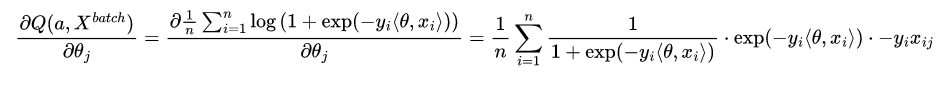

Расчёт градиента в матричном виде:

In [ ]:
def gradient(theta, X, y):
  yModified = np.where(y == 0, -1, 1)
  expHi = np.exp(-yModified * np.dot(X, theta))
  expLo = 1 + expHi
  fraction = -yModified * expHi / expLo
  result = np.dot(fraction, X) / X.shape[0]
  return result

assert gradient(theta, X, y).shape == theta.shape, 'Неверный размер массива'

Функция обучения уже реализована

In [ ]:
def fit(X, y, batch_size=10, h=0.05,  iters=100, plot=True):

    # получаем размерности матрицы
    size, dim = X.shape

    # случайная начальная инициализация
    theta = np.random.uniform(size=dim)

    errors = []

    theta_history = theta
    colors = [plt.get_cmap('gist_rainbow')(i) for i in np.linspace(0,1,dim)]

    # plt
    if plot:
        fig = plt.figure(figsize=(15, 10))
        ax1 = fig.add_subplot(221)
        ax2 = fig.add_subplot(222)
        ax3 = fig.add_subplot(212)
        fig.suptitle('Gradient descent')


    for _ in range(iters):

        # берём случайный набор элементов
        batch = np.random.choice(size, batch_size, replace=False)
        X_batch = X[batch]
        y_batch = y[batch]

        # считаем производные
        grad = gradient(theta, X_batch, y_batch)

        assert type(grad) == np.ndarray, 'неверный тип'
        assert len(grad.shape) == 1, 'Необходимо вернуть одномерный вектор'
        assert grad.shape[0] == len(theta), 'длина вектора должна быть равной количеству весов'


        # Обновляем веса

        theta -= grad * h

        theta_history = np.vstack((theta_history, theta))

        # error
        loss = logloss(theta, X, y)
        errors.append(loss)

        if plot:
            ax1.clear()
            ax1.scatter(range(dim), theta, label='Gradient solution')
            ax1.legend(loc="upper left")
            ax1.set_title('theta')
            ax1.set_ylabel(r'$\bar \beta$')
            ax1.set_xlabel('weight ID')


            ax2.plot(range(_+1), errors, 'g-')
            ax2.set_title('logloss')
            ax2.set_xlabel('itarations')

            ax3.plot(theta_history)
            ax3.set_title('update theta')
            ax3.set_ylabel('value')
            ax3.set_xlabel('itarations')
            time.sleep(0.05)
            fig.canvas.draw()

    return theta

Тест собственной реализации на сгенерированных данных и сравнение с библиотечной логистической регрессией:

In [ ]:
X, y = make_classification(n_samples=20000)

In [ ]:
optimal_theta = fit(X, y, plot=False)
y_pred = binary_class_prediction(optimal_theta, X)
print('Скор на собственной реализации:', accuracy_score(y, y_pred))

Скор на собственной реализации: 0.83455


In [ ]:
LR_test = LogisticRegression()
LR_test.fit(X, y)
y_pred = LR_test.predict(X)
accuracy_score(y, y_pred)
print('Скор на библиотечной реализации:', accuracy_score(y, y_pred))

Скор на библиотечной реализации: 0.88135


Видно, что у библиотечной реализации LogisticRegression() немного лучше результаты, чем у кастомной. Но в целом, наша обучающая модель справляется неплохо. Осталось посмотреть, как она будет работать на более реальных данных.

**Применение собственной реализации логистической регрессии для предсказания погоды**

In [ ]:
print('Результаты работы и замера времени работы при дефолтных параметрах:\n')
start = time.time()
tet = fit(x_train, y_train, plot = False)
end = time.time()
print("Время обучения: {}".format(end - start))
start = time.time()
y_pred = binary_class_prediction(tet, x_train)
end = time.time()
print("Время предсказания для тренировочной выборки: {}".format(end - start))
accuracyTrain = accuracy_score(y_train, y_pred)
start = time.time()
y_pred = binary_class_prediction(tet, x_test)
end = time.time()
print("Время предсказания для тестовой выборки: {}".format(end - start))
accuracyTest = accuracy_score(y_test, y_pred)
print("Accuracy Train: {:.2f}%".format(accuracyTrain * 100))
print("Accuracy Test: {:.2f}%".format(accuracyTest * 100))


Результаты работы и замера времени работы при дефолтных параметрах:

Время обучения: 1.2660717964172363
Время предсказания для тренировочной выборки: 0.00438380241394043
Время предсказания для тестовой выборки: 0.0016391277313232422
Accuracy Train: 67.98%
Accuracy Test: 69.55%


При дефолтных значениях модель показывает не очень хороший скор. Попробуем немного изменить параметры нашей модели и посмотрим на скор и время выполнения при разных n_iters (количество интераций - параметр нашей модели)

In [ ]:
fittingTimesDict = {}
trainPredTimesDict = {}
testPredTimesDict = {}
scoresTrain = {}
scoresTest = {}
for n_it in range(500, 5500, 500):
  start = time.time()
  tet = fit(x_train, y_train, plot = False, iters = n_it)
  end = time.time()
  fittingTimesDict[n_it] = round(end - start, 2)
  start = time.time()
  y_pred = binary_class_prediction(tet, x_train)
  end = time.time()
  trainPredTimesDict[n_it] = round(end - start, 2)
  scoresTrain[n_it] = round(accuracy_score(y_train, y_pred) * 100, 2)
  start = time.time()
  y_pred = binary_class_prediction(tet, x_test)
  end = time.time()
  testPredTimesDict[n_it] = round(end - start, 2)
  scoresTest[n_it] = round(accuracy_score(y_test, y_pred) * 100, 2)
print('Вывод времени обучения для каждого iters = 500..5000\n\n', fittingTimesDict)
print('\nВывод времени предсказания тренировочной выборки для каждого iters = 500..5000\n\n', trainPredTimesDict)
print('\nВывод времени предсказания тестовой выборки для каждого iters = 500..5000\n\n', testPredTimesDict)
print('\nВывод скора на тренировочной выборке для каждого iters = 500..5000\n\n', scoresTrain)
print('\nВывод скора на тестовой выборке для каждого iters = 500..5000\n\n', scoresTest)

Вывод времени обучения для каждого iters = 500..5000

 {500: 7.24, 1000: 13.61, 1500: 20.39, 2000: 27.76, 2500: 33.54, 3000: 41.22, 3500: 48.77, 4000: 54.37, 4500: 62.17, 5000: 84.19}

Вывод времени предсказания тренировочной выборки для каждого iters = 500..5000

 {500: 0.01, 1000: 0.01, 1500: 0.0, 2000: 0.0, 2500: 0.0, 3000: 0.0, 3500: 0.01, 4000: 0.01, 4500: 0.0, 5000: 0.0}

Вывод времени предсказания тестовой выборки для каждого iters = 500..5000

 {500: 0.0, 1000: 0.01, 1500: 0.0, 2000: 0.0, 2500: 0.0, 3000: 0.0, 3500: 0.01, 4000: 0.01, 4500: 0.0, 5000: 0.0}

Вывод скора на тренировочной выборке для каждого iters = 500..5000

 {500: 69.81, 1000: 71.13, 1500: 71.85, 2000: 70.85, 2500: 72.64, 3000: 70.57, 3500: 71.23, 4000: 72.17, 4500: 71.57, 5000: 72.71}

Вывод скора на тестовой выборке для каждого iters = 500..5000

 {500: 72.7, 1000: 73.97, 1500: 74.01, 2000: 73.07, 2500: 74.76, 3000: 72.98, 3500: 76.19, 4000: 74.47, 4500: 73.99, 5000: 74.74}


7) **Выводы.**

- Была произведена работа над признаками. В ходе этой работы выяснилось, что есть признаки с большими и систематическими пропусками, которые не могли быть абсолютно случайными. Была произведена попытка их удаления, что-то удалилось, частично это помогло. Но некоторые признаки к сожалению не получилось заполнить. Был сделан вывод, что они не особо важны для предсказания (поэтому они заполнялись без особой усидчивости), и я решил их удалить. Так же были удалены признаки, имевшие крайне низкую корреляцию с целевой переменной. Были удалены так же и ненужные признаки.

- Была опробована библиотечная реализация логистической регрессии для обучения. Скор получился довольно неплохим с учётом того, что мы удалили некоторые признаки из-за плохой заполненности. Время его работы оказалось довольно быстрым.

- Так же для пробы была выбрана библиотечная реализация метода k-ближайших соседей. В ходе теста при различных k оказалось, что время прогнозирования по этой модели достаочно долгое. При k = 10 получился наилучший скор на тестовой выборке, сравнимый с логистической регрессией.

- Третий библиотечный метод, на котором была построена модель прогнозирования, это гауссов наивный байесовский классификатор. У него результаты оказались хуже всех, но время обучения и предсказания быстрее всех.

- Четвёртый метод логистической регрессии, который обучал модель дляпрогнозирования погоды, был реализован самостоятельно. При дефолтных параметрах он показал не очень хороший результат. При увеличении количества итераций скор улучшился на 10%, но увеличилось время выполнения. В целом своя реализация логистической регрессии показала результаты несколько хуже библиотечной логистической регрессии. Скорее всего это связано с тем, что в библиотечном методе используются дополнительные оптимизации и улучшения (lbfgs решатель из семейства квази-ньютоновских методов, L2 регуляризация), которых нет в нашей. Но в целом своя реализация справляется неплохо.

Таким образом, наилучшие результаты даёт библиотечная модель логистической регрессии. И это не удивительно, ведь её концепция довольно проста, и для большинства задач она хорошо должна подходить. Чем проще модель, тем она универсальнее.